# Package registries (npm, PyPI)

_Part of the **Decay Before Archival** project — see `README.md` for full project context, setup instructions, and links to the other notebooks (`deps_dev.ipynb`, `scorecard.ipynb`, `gh_archive.ipynb`, `pypi.ipynb`, `other_sources.ipynb`)._

## Question: do registry APIs add anything beyond deps.dev?

deps.dev already mirrors npm and PyPI, so the registries only help if they give us something deps.dev doesn't. Checked against the label (`inactive_next_365d`, cutoff 2025-01-01) and the leakage rules in `deps_dev.ipynb`:

| Registry field | Already in deps.dev? | Safe as a 2024 feature? | Verdict |
|---|---|---|---|
| Version publish dates (npm `time`, PyPI `releases[*].upload_time`) | Yes (`PackageVersions.UpstreamPublishedAt`) | Yes, filter to `< 2025-01-01` | Redundant. Only useful to fill the ~201 packaged repos with no publish timestamp |
| **Download counts, npm** (`api.npmjs.org/downloads/range/...`) | No | **Yes**, daily history back to 2015 | **New.** Usage level plus H1 -> H2 trend (demand decay) |
| **Download counts, PyPI** | No | Yes, but not through the REST API (see below) | **New**, but needs BigQuery |
| Maintainers / owners | No | **No**, current state only | Leakage |
| `deprecated` message (npm), `yanked` (PyPI) | Partly (`Deprecated`) | **No**, no deprecation date | Label candidate only, same as deps.dev |
| `dist-tags`, latest version, `modified` | Yes | **No**, current state | Leakage |

**PyPI downloads:** `pypistats.org` only keeps ~180 days, and the `downloads` field in `pypi.org/pypi/<pkg>/json` is `-1` (deprecated). Downloads for 2024 have to come from `bigquery-public-data.pypi.file_downloads`. That is the `pypi.ipynb` source in the README, so the PyPI part here is a dry-run only and should be coordinated with whoever owns that notebook.

**Limit on coverage:** every registry lookup starts from a package name, and the only repo -> package link we have is deps.dev's. So this can enrich at most the ~951 repos with a published package (~1.5% of 62,581), not widen the universe. First step below is to see how many of those are npm or PyPI at all.

**What this notebook tests:** whether download level and H1 -> H2 trend separate repos that go inactive in 2025 from those that don't. If they don't, drop the registries and keep deps.dev.

In [1]:
import time
from pathlib import Path

import pandas as pd
import requests
from google.cloud import bigquery
from decay_before_archival import get_client

client = get_client()
DATA = Path("../data")

## Step 1: package names for our packaged repos

deps.dev's CSV is rolled up to repo level and has no package names, so pull `(repo, System, Name)` once from `PackageVersionToProject` at `SNAP_END` (~9 GB, same scan size as the coverage query) and cache it. Delete the CSV to re-run.

In [2]:
PKG_CSV = DATA / "deps_dev_package_names_2024.csv"
# Last weekly snapshot before the 2025-01-01 cutoff (see deps_dev.ipynb). Look it up: it has a time of day (2024-12-30 21:00:45 UTC),
# so a hard-coded midnight timestamp matches nothing and silently returns 0 rows.
SNAP_END = next(iter(client.query("SELECT MAX(Time) AS t FROM `bigquery-public-data.deps_dev_v1.Snapshots` WHERE Time < TIMESTAMP('2025-01-01')").result())).t

repo_names = (
    pd.read_csv(DATA / "gh_archive_results_clean.csv", usecols=["repo_full_name"])
    ["repo_full_name"].str.lower().unique().tolist()
)

PKG_QUERY = """
SELECT DISTINCT LOWER(ProjectName) AS repo_full_name_lower, System, Name
FROM `bigquery-public-data.deps_dev_v1.PackageVersionToProject`
WHERE SnapshotAt = @snap_end AND ProjectType = 'GITHUB' AND RelationType = 'SOURCE_REPO_TYPE'
  AND LOWER(ProjectName) IN UNNEST(@repos)
"""
cfg = lambda dry: bigquery.QueryJobConfig(dry_run=dry, query_parameters=[
    bigquery.ArrayQueryParameter("repos", "STRING", repo_names),
    bigquery.ScalarQueryParameter("snap_end", "TIMESTAMP", SNAP_END),
])

if PKG_CSV.exists():
    pkgs = pd.read_csv(PKG_CSV)
else:
    job = client.query(PKG_QUERY, job_config=cfg(True))
    print(f"This query will process {job.total_bytes_processed / 1e9:.2f} GB")
    pkgs = client.query(PKG_QUERY, job_config=cfg(False)).to_dataframe()
    assert len(pkgs) > 0, "0 rows: check SNAP_END matches a real snapshot time"  # never cache an empty result
    pkgs.to_csv(PKG_CSV, index=False)

print(f"{len(pkgs):,} (repo, package) pairs | {pkgs['repo_full_name_lower'].nunique():,} repos")

4,782 (repo, package) pairs | 951 repos


In [3]:
# How many packaged repos can each registry actually reach?
by_system = pkgs.groupby("System").agg(packages=("Name", "nunique"), repos=("repo_full_name_lower", "nunique"))
by_system.sort_values("repos", ascending=False)

,packages,repos
System,,
GO,338,320
NPM,3343,296
PYPI,234,189
MAVEN,610,70
CARGO,145,60
NUGET,112,45


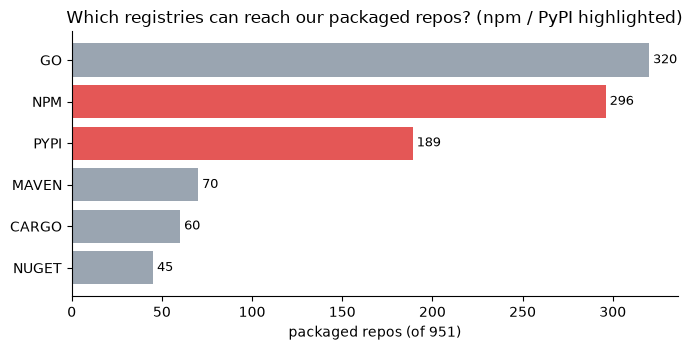

npm or PyPI reaches 480 of 951 packaged repos (50.5%), i.e. 0.77% of the 62,581 GH Archive repos


In [4]:
import matplotlib.pyplot as plt

FIG_DIR = Path("../figures")

def save_svg(fig, name):
    """Write a figure to figures/ as SVG (no timestamp, so re-runs give clean diffs)."""
    fig.savefig(FIG_DIR / name, bbox_inches="tight", metadata={"Date": None})

# Repos per ecosystem (a repo can publish to several, so the bars overlap) and how many registries we could actually query.
eco = by_system["repos"].sort_values()
fig, ax = plt.subplots(figsize=(7, 3.6))
colors = ["#E45756" if s in ("NPM", "PYPI") else "#9aa5b1" for s in eco.index]
bars = ax.barh(eco.index, eco.values, color=colors)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel("packaged repos (of 951)")
ax.set_title("Which registries can reach our packaged repos? (npm / PyPI highlighted)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); save_svg(fig, "registries_repos_per_ecosystem.svg"); plt.show()

reach = pkgs.loc[pkgs["System"].isin(["NPM", "PYPI"]), "repo_full_name_lower"].nunique()
total_pkg = pkgs["repo_full_name_lower"].nunique()
print(f"npm or PyPI reaches {reach} of {total_pkg} packaged repos ({100 * reach / total_pkg:.1f}%), i.e. {100 * reach / len(repo_names):.2f}% of the {len(repo_names):,} GH Archive repos")

**Assignment item:** Data Preprocessing → *visualize key variables as tables / charts* and *how many samples matched vs lost* (here: how far registry coverage reaches).

**What it shows:** the 951 packaged repos publish 4,782 (repo, package) pairs across six ecosystems. Go is the biggest (320 repos), then npm (296), PyPI (189), Maven (70), Cargo (60) and NuGet (45); repos in several ecosystems are counted in each, so the bars overlap. npm or PyPI reaches **480 of 951** packaged repos (50.5%), which is only **0.77%** of the 62,581 GH Archive repos. Even a complete npm + PyPI download dataset would cover under 1% of rows, which supports the decision below.

**Missing values / cleaning:** the package-name file has no missing values (every row has a repo, system and name). The first version of Step 1 returned 0 rows because it hard-coded the snapshot as midnight, but the real snapshot is `2024-12-30 21:00:45 UTC`. It now looks the snapshot up and refuses to cache an empty result.

**Notes:**

Step 1 was run: 4,782 (repo, package) pairs for all 951 packaged repos (~9.2 GB scanned; cached in `data/deps_dev_package_names_2024.csv`). The ecosystem split is in the chart above. The registry download steps (2 and 4) were not run for the full set, so no registry download numbers are used anywhere. The decision below still rests on the lift test, and the coverage numbers above now back it up.

## Step 2: npm downloads (2024 only)

`api.npmjs.org/downloads/range/<start>:<end>/<pkg>` returns daily counts and, unlike the packument, is point-in-time safe: we ask for 2024 only. Scoped names (`@scope/name`) go in the URL as-is. No API key; keep it polite (sequential, short sleep). A repo can publish several npm packages, so roll up to repo with sums and a max like we did for deps.dev.

In [ ]:
SESSION = requests.Session()


def get_json(url, tries=3):
    """GET -> parsed JSON, None on 404, retry with backoff on 429/5xx."""
    for i in range(tries):
        r = SESSION.get(url, timeout=30)
        if r.status_code == 404:
            return None
        if r.status_code == 429 or r.status_code >= 500:
            time.sleep(2 ** i)
            continue
        r.raise_for_status()
        return r.json()
    return None


def npm_downloads_2024(name):
    d = get_json(f"https://api.npmjs.org/downloads/range/2024-01-01:2024-12-31/{name}")
    if not d:
        return None
    days = d["downloads"]
    return {
        "npm_downloads_h1_2024": sum(x["downloads"] for x in days if x["day"] < "2024-07-01"),
        "npm_downloads_h2_2024": sum(x["downloads"] for x in days if x["day"] >= "2024-07-01"),
    }


npm_pkgs = pkgs[pkgs["System"] == "NPM"]
print(f"{len(npm_pkgs):,} npm packages")

In [ ]:
# Start with a small sample to check the output looks right; set N_SAMPLE = None for the full run (~1 request per package).
N_SAMPLE = 50
NPM_CSV = DATA / "npm_downloads_2024.csv"

todo = npm_pkgs if N_SAMPLE is None else npm_pkgs.sample(min(N_SAMPLE, len(npm_pkgs)), random_state=0)
rows = []
for r in todo.itertuples():
    res = npm_downloads_2024(r.Name)
    rows.append({"repo_full_name_lower": r.repo_full_name_lower, "Name": r.Name, **(res or {})})
    time.sleep(0.1)

npm = pd.DataFrame(rows)
print(f"{npm['npm_downloads_h1_2024'].notna().sum()} / {len(npm)} packages returned downloads")
if N_SAMPLE is None:
    npm.to_csv(NPM_CSV, index=False)
npm.head()

In [ ]:
# Roll up to repo level: sum downloads over the repo's npm packages, then a log-scale trend H2 vs H1.
import numpy as np

npm_repo = (
    npm.groupby("repo_full_name_lower")[["npm_downloads_h1_2024", "npm_downloads_h2_2024"]]
    .sum(min_count=1)
    .assign(npm_downloads_2024=lambda d: d["npm_downloads_h1_2024"] + d["npm_downloads_h2_2024"])
)
npm_repo["npm_log_downloads_2024"] = np.log1p(npm_repo["npm_downloads_2024"])
npm_repo["npm_downloads_trend"] = np.log1p(npm_repo["npm_downloads_h2_2024"]) - np.log1p(npm_repo["npm_downloads_h1_2024"])
npm_repo.describe().T

## Step 3: does it separate the label?

Join the repo-level npm numbers to the GH Archive label. Only meaningful on the full run (`N_SAMPLE = None`); on a 50-package sample this is just a smoke test. Compare the inactive rate by download quartile and by trend direction. For reference, the overall rate is 85.6% outside deps.dev, 63.9% in deps.dev without a package, and 43.5% with a package, so the question is whether downloads explain anything *within* the packaged group.

In [ ]:
gh = pd.read_csv(DATA / "gh_archive_results_clean.csv", usecols=["repo_full_name", "inactive_next_365d"])
gh["repo_full_name_lower"] = gh["repo_full_name"].str.lower()
gh = gh.drop_duplicates("repo_full_name_lower", keep="last")  # 46 names repeat with different repo_id (see integrate_datasets.ipynb)

j = npm_repo.reset_index().merge(gh[["repo_full_name_lower", "inactive_next_365d"]], on="repo_full_name_lower", how="left")
print(f"{len(j)} npm repos | {j['inactive_next_365d'].notna().sum()} matched to a GH Archive label")

j["downloads_quartile"] = pd.qcut(j["npm_log_downloads_2024"], 4, labels=["Q1 low", "Q2", "Q3", "Q4 high"], duplicates="drop")
j["trend_down"] = j["npm_downloads_trend"] < 0
for col in ["downloads_quartile", "trend_down"]:
    print(j.groupby(col, observed=True)["inactive_next_365d"].agg(["mean", "count"]).round(3), "\n")

## Step 4: PyPI downloads (dry-run only)

Needs `bigquery-public-data.pypi.file_downloads`, which is partitioned by day, so the 2024 date filter is what controls cost. Names must be PEP 503-normalized to match (`re.sub(r"[-_.]+", "-", name).lower()`). Wrapping the table column in a function would defeat clustering, so normalize on our side. Check the dry-run number before flipping the flag, and agree with the `pypi.ipynb` owner first.

In [ ]:
import re

RUN_PYPI_DOWNLOADS = False
pypi_names = sorted({re.sub(r"[-_.]+", "-", n).lower() for n in pkgs.loc[pkgs["System"] == "PYPI", "Name"]})

PYPI_QUERY = """
SELECT project,
       COUNTIF(timestamp <  TIMESTAMP('2024-07-01')) AS pypi_downloads_h1_2024,
       COUNTIF(timestamp >= TIMESTAMP('2024-07-01')) AS pypi_downloads_h2_2024
FROM `bigquery-public-data.pypi.file_downloads`
WHERE timestamp >= TIMESTAMP('2024-01-01') AND timestamp < TIMESTAMP('2025-01-01')
  AND project IN UNNEST(@names)
GROUP BY project
"""
pypi_cfg = lambda dry: bigquery.QueryJobConfig(dry_run=dry, query_parameters=[
    bigquery.ArrayQueryParameter("names", "STRING", pypi_names)])

job = client.query(PYPI_QUERY, job_config=pypi_cfg(True))
print(f"{len(pypi_names):,} PyPI packages | this query will process {job.total_bytes_processed / 1e9:.2f} GB")

if RUN_PYPI_DOWNLOADS:
    pypi_dl = client.query(PYPI_QUERY, job_config=pypi_cfg(False)).to_dataframe()
    pypi_dl.to_csv(DATA / "pypi_downloads_2024.csv", index=False)
    print(f"wrote {len(pypi_dl):,} rows")

## Step 5: lift test for the sparse sources (reproduces the decision below)

Does adding deps.dev or Scorecard columns improve a model over GH Archive alone? 5-fold cross-validated `HistGradientBoostingClassifier` (handles NaN natively, so unmatched repos stay missing instead of being imputed), scored by ROC AUC. Scorecard comes from `data/scorecard_gh_sample.csv` on `origin/britney/gh`; if that file isn't on this branch the Scorecard row is skipped.

In [5]:
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict

gh_all = pd.read_csv(DATA / "gh_archive_results_clean.csv")
gh_all["k"] = gh_all["repo_full_name"].str.lower()
gh_all = gh_all.drop_duplicates("k", keep="last")

deps = pd.read_csv(DATA / "deps_dev_features_2024.csv").rename(columns={"repo_full_name_lower": "k"})
m = gh_all.merge(deps, on="k", how="left")
m["in_depsdev"] = m["in_projects"].notna().astype(int)
m["has_package"] = (m["n_packages"].fillna(0) > 0).astype(int)
m["in_projects"] = m["in_projects"].astype(float)

SC_CSV = DATA / "scorecard_gh_sample.csv"
if SC_CSV.exists():
    sc = pd.read_csv(SC_CSV)
    sc["k"] = sc["repo_name"].str.lower()
    m = m.merge(sc.drop_duplicates("k")[["k", "scorecard_score"]], on="k", how="left")

y = m["inactive_next_365d"].values
gh_cols = [c for c in gh_all.columns if c not in ("repo_id", "repo_full_name", "cutoff_date", "inactive_next_365d", "k")]
deps_cols = [c for c in deps.columns if c != "k"] + ["in_depsdev", "has_package"]


def cv_auc(cols, mask=None):
    mask = np.ones(len(m), bool) if mask is None else mask
    X = m.loc[mask, cols].astype(float)
    p = cross_val_predict(HistGradientBoostingClassifier(max_iter=200, random_state=0), X, y[mask],
                          cv=StratifiedKFold(5, shuffle=True, random_state=0), method="predict_proba")[:, 1]
    return roc_auc_score(y[mask], p)


packaged = (m["has_package"] == 1).values
has_sc = "scorecard_score" in m
rows = [
    ("All repos", len(m), cv_auc(gh_cols), cv_auc(gh_cols + deps_cols),
     cv_auc(gh_cols + deps_cols + ["scorecard_score"]) if has_sc else np.nan),
    ("Packaged repos", int(packaged.sum()), cv_auc(gh_cols, packaged), cv_auc(gh_cols + deps_cols, packaged), np.nan),
]
if has_sc:
    sm = m["scorecard_score"].notna().values
    rows.append(("Scorecard repos", int(sm.sum()), cv_auc(gh_cols, sm), cv_auc(gh_cols + deps_cols, sm),
                 cv_auc(gh_cols + deps_cols + ["scorecard_score"], sm)))
pd.DataFrame(rows, columns=["set", "n", "GH only", "+ deps.dev", "+ Scorecard"]).round(3)

,set,n,GH only,+ deps.dev,+ Scorecard
0,All repos,62581,0.842,0.843,0.843
1,Packaged repos,951,0.846,0.851,NaN
2,Scorecard repos,287,0.862,0.865,0.876


**Notes:**

- Registry data was not collected for the full set. The npm cells were only smoke-tested on a handful of packages and the PyPI query is a dry-run, so no registry numbers are used anywhere in the project.
- The decision below rests on a lift test of the *other* sparse sources (deps.dev, Scorecard), which are strictly better covered than the registries. Registry coverage is a subset of deps.dev's.

## Decision: we are not using the package registries

**Test:** 5-fold cross-validated gradient boosting on `inactive_next_365d`, with the GH Archive features alone and then with each extra source added (missing left as missing). Scorecard numbers use `origin/britney/gh` (`data/scorecard_gh_sample.csv`, not merged into this branch yet).

| Set | GH Archive only | + deps.dev | + Scorecard |
|---|---|---|---|
| All 62,581 repos | 0.842 | 0.843 | 0.843 |
| 951 packaged repos | 0.846 | 0.851 | n/a |
| 287 Scorecard repos | 0.862 | 0.865 | 0.876 |

**Why the registries are out:**

1. **Little to gain.** GH Archive carries almost all the signal (AUC 0.84). deps.dev, which has better coverage than any registry, adds about +0.001 over the full set. Registry downloads can only be a subset of that.
2. **Coverage ceiling.** Registry lookups start from package names, and our only repo -> package link is deps.dev. So registries can enrich at most the ~951 packaged repos (~1.5% of 62,581) and can't widen the universe.
3. **Redundant fields.** Publish dates are already in deps.dev (`PackageVersions.UpstreamPublishedAt`).
4. **Leakage.** Maintainers, `deprecated`, latest version and `modified` are current state with no dates, so they can't be 2024 features.
5. **PyPI cost and overlap.** 2024 downloads exist only in `bigquery-public-data.pypi.file_downloads` (the REST API has 180 days or `-1`), and that belongs to `pypi.ipynb`.
6. **npm only.** npm 2024 downloads are the one new, leakage-safe signal, but they cover only the npm subset of an already-small group.

**What we do instead:** keep deps.dev and Scorecard as optional columns and as binary indicators for the mining assignment (`has_package`, `scorecard_score>4.4`); both separate the label descriptively (Scorecard tertiles: 48% / 19% / 6% inactive) even though they don't help a classifier. Put the feature effort into GH Archive (contributor concentration, issue time-to-close, a 2023 baseline).

**Caveats:** the 287-repo Scorecard lift (+0.01) is within noise for that sample size, and the Scorecard score probably encodes recent activity already. One CV run, no repeated seeds.

**Revisit if:** the team changes the universe to package-first (deps.dev defines the repos). Then registry downloads become relevant to nearly every row and this test should be re-run.